In [2]:
pip install -q matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path

# ---- Prefer your original cars.csv explicitly ----
# Edit this if your file lives somewhere else.
PREFERRED = [
    Path("/workspaces/used-car-price-app/data/new/cars.csv"),
    Path("data/cars.csv"),
    Path("data/new/cars.csv"),
    *Path("data").glob("**/cars.csv"),
]

found = next((p for p in PREFERRED if p.exists()), None)
if not found:
    raise FileNotFoundError(
        "Couldn't find cars.csv. Put it at project root or under data/, "
        "or update the PREFERRED list above."
    )

DATA_CSV = str(found)   # this variable is used by later cells
print("Using cars.csv at:", DATA_CSV)

Using cars.csv at: /workspaces/used-car-price-app/data/new/cars.csv


In [9]:
pip install -q seaborn missingno

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os, re, json, unicodedata, io, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

In [12]:
def read_table_smart(path: Path) -> pd.DataFrame:
    sfx = path.suffix.lower()
    if sfx in (".xlsx", ".xls"):
        return pd.read_excel(path)

    # Peek header for BOM + delimiter
    with open(path, "rb") as fb:
        head = fb.read(256 * 1024)

    enc_guess = None
    if head.startswith(b"\xff\xfe"): enc_guess = "utf-16-le"
    elif head.startswith(b"\xfe\xff"): enc_guess = "utf-16-be"
    elif head.startswith(b"\xef\xbb\xbf"): enc_guess = "utf-8-sig"

    try:
        sample_txt = head.decode(enc_guess or "utf-8", errors="replace")
        sep_guess = csv.Sniffer().sniff(sample_txt, delimiters=[",",";","\t","|"]).delimiter
    except Exception:
        sep_guess = None

    tries = []
    if enc_guess or sep_guess:
        tries.append((enc_guess or "utf-8", sep_guess or ","))

    encodings = ["utf-8","utf-8-sig","utf-16","utf-16-le","utf-16-be","latin1"]
    seps = [",",";","\t","|"]
    for e in encodings:
        for s in seps:
            if (e,s) not in tries:
                tries.append((e,s))

    last_err = None
    for e,s in tries:
        try:
            df = pd.read_csv(path, encoding=e, sep=s)
            if df.shape[1] > 1:
                return df
        except Exception as err:
            last_err = err
            continue
    raise RuntimeError(f"Failed to parse {path}. Last error: {last_err}")

df_raw = read_table_smart(Path(DATA_CSV))
df_raw.head(3)

,Brand,Model,Year,Status,Mileage,Dealer,Price
0,Mazda,CX-5,2023,New,NaN,NaN,36703.0
1,Kia,Sportage,2023,New,NaN,Classic Kia,28990.0
2,Chevrolet,Camaro,2024,New,NaN,Classic Chevrolet Beaumont,41425.0


In [14]:
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.sample(min(5, len(df_raw)), random_state=1))

Shape: (144867, 7)
Columns: ['Brand', 'Model', 'Year', 'Status', 'Mileage', 'Dealer', 'Price']


,Brand,Model,Year,Status,Mileage,Dealer,Price
93800,Toyota,Corolla,2015,Used,78219.0,Sheehy Honda,13813.0
40484,Mazda,CX-9,2021,Used,26526.0,Safford Hyundai of Springfield,29000.0
6175,Honda,Odyssey,2019,Used,45700.0,Hawkinson Kia,27000.0
142188,Nissan,Murano,2023,New,NaN,Fort Collins Nissan,41149.0
44876,Audi,SQ5,2023,New,NaN,Audi Devon,70670.0


In [15]:
def _norm(s: str) -> str:
    import unicodedata, re
    s = unicodedata.normalize("NFKD", str(s)).lower()
    s = re.sub(r"[^a-z0-9]+"," ", s)
    return re.sub(r"\s+"," ", s).strip()

def find_col(cands, cols):
    norm_cols = {_norm(c): c for c in cols}
    for cand in cands:
        n = _norm(cand)
        if n in norm_cols: return norm_cols[n]
        for nc, orig in norm_cols.items():
            if n and n in nc: return orig
    return None

cols = df_raw.columns.tolist()
mapping = {
    find_col(["price","list_price","selling_price","price_usd","current_price","final_price","pricesold"], cols): "price",
    find_col(["year","model_year","registration_year","year_built","year_of_manufacture"], cols): "year",
    find_col(["mileage","odometer","odometer_value","miles","miles_driven","km","kilometers"], cols): "mileage",
    find_col(["make","brand","manufacturer","make_name"], cols): "make",
    find_col(["model","model_name","car_model","trim","variant"], cols): "model",
    find_col(["state","state_code","region","province"], cols): "state",
    find_col(["fuel","fuel_type","fueltype"], cols): "fuel",
    find_col(["transmission","gearbox","transmission_type"], cols): "transmission",
    find_col(["condition","vehicle_condition","car_condition"], cols): "condition",
    find_col(["body","body_type","bodystyle","body_style"], cols): "body",
    find_col(["title_status","title","title_status_desc"], cols): "title_status",
    find_col(["seller_type","seller","seller_category","dealer_type"], cols): "seller_type",
    find_col(["listed_at","posting_date","date","created_at","listing_date"], cols): "listing_date",
}
mapping = {k:v for k,v in mapping.items() if k is not None}
print("Column mapping ->", mapping)
df = df_raw.rename(columns=mapping).copy()
df.head(3)

Column mapping -> {'Price': 'price', 'Year': 'year', 'Mileage': 'mileage', 'Brand': 'make', 'Model': 'model'}


,make,model,year,Status,mileage,Dealer,price
0,Mazda,CX-5,2023,New,NaN,NaN,36703.0
1,Kia,Sportage,2023,New,NaN,Classic Kia,28990.0
2,Chevrolet,Camaro,2024,New,NaN,Classic Chevrolet Beaumont,41425.0


In [16]:
def parse_price_series(s: pd.Series) -> pd.Series:
    x = (s.astype(str).str.strip()
         .str.replace(r"[^\d\.\,\-kK]", "", regex=True)
         .str.replace(",", "", regex=False))
    kmask = x.str.contains(r"[kK]$", na=False)
    out = pd.to_numeric(x.str.replace(r"[kK]$", "", regex=True), errors="coerce")
    out[kmask] = out[kmask] * 1000.0
    return out.replace([np.inf,-np.inf], np.nan)

if "price" in df:    df["price"]    = parse_price_series(df["price"])
if "year" in df:     df["year"]     = pd.to_numeric(df["year"], errors="coerce")
if "mileage" in df:  df["mileage"]  = pd.to_numeric(df["mileage"], errors="coerce")

# km → miles by name or heuristic
mileage_unit = "miles"
miles_src = next((c for c in mapping if mapping.get(c)=="mileage"), None)
if miles_src and _norm(miles_src) in ("km","kilometers"):
    df["mileage"] = df["mileage"] * 0.621371
    mileage_unit = "kilometers"
else:
    med = df["mileage"].median(skipna=True) if "mileage" in df else np.nan
    if pd.notna(med) and med > 350_000:
        df["mileage"] = df["mileage"] * 0.621371
        mileage_unit = "kilometers*heuristic"

print("Mileage unit detected:", mileage_unit)

# Basic sanity flags
issues = {}
if "price" in df:
    issues["neg_price"]   = int((df["price"] < 0).sum())
    issues["zero_price"]  = int((df["price"] == 0).sum())
if "mileage" in df:
    issues["neg_mileage"] = int((df["mileage"] < 0).sum())
if "year" in df:
    y = df["year"].dropna()
    if not y.empty:
        issues["year_min"] = int(y.min())
        issues["year_max"] = int(y.max())
issues

Mileage unit detected: miles


{'neg_price': 0,
 'zero_price': 0,
 'neg_mileage': 0,
 'year_min': 1959,
 'year_max': 2024}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   make     144867 non-null  object 
 1   model    144867 non-null  object 
 2   year     144867 non-null  int64  
 3   Status   144867 non-null  object 
 4   mileage  55914 non-null   float64
 5   Dealer   144539 non-null  object 
 6   price    140956 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 40.0 MB



,null_fraction
mileage,0.614032
price,0.026997
Dealer,0.002264
year,0.000000
model,0.000000
make,0.000000
Status,0.000000


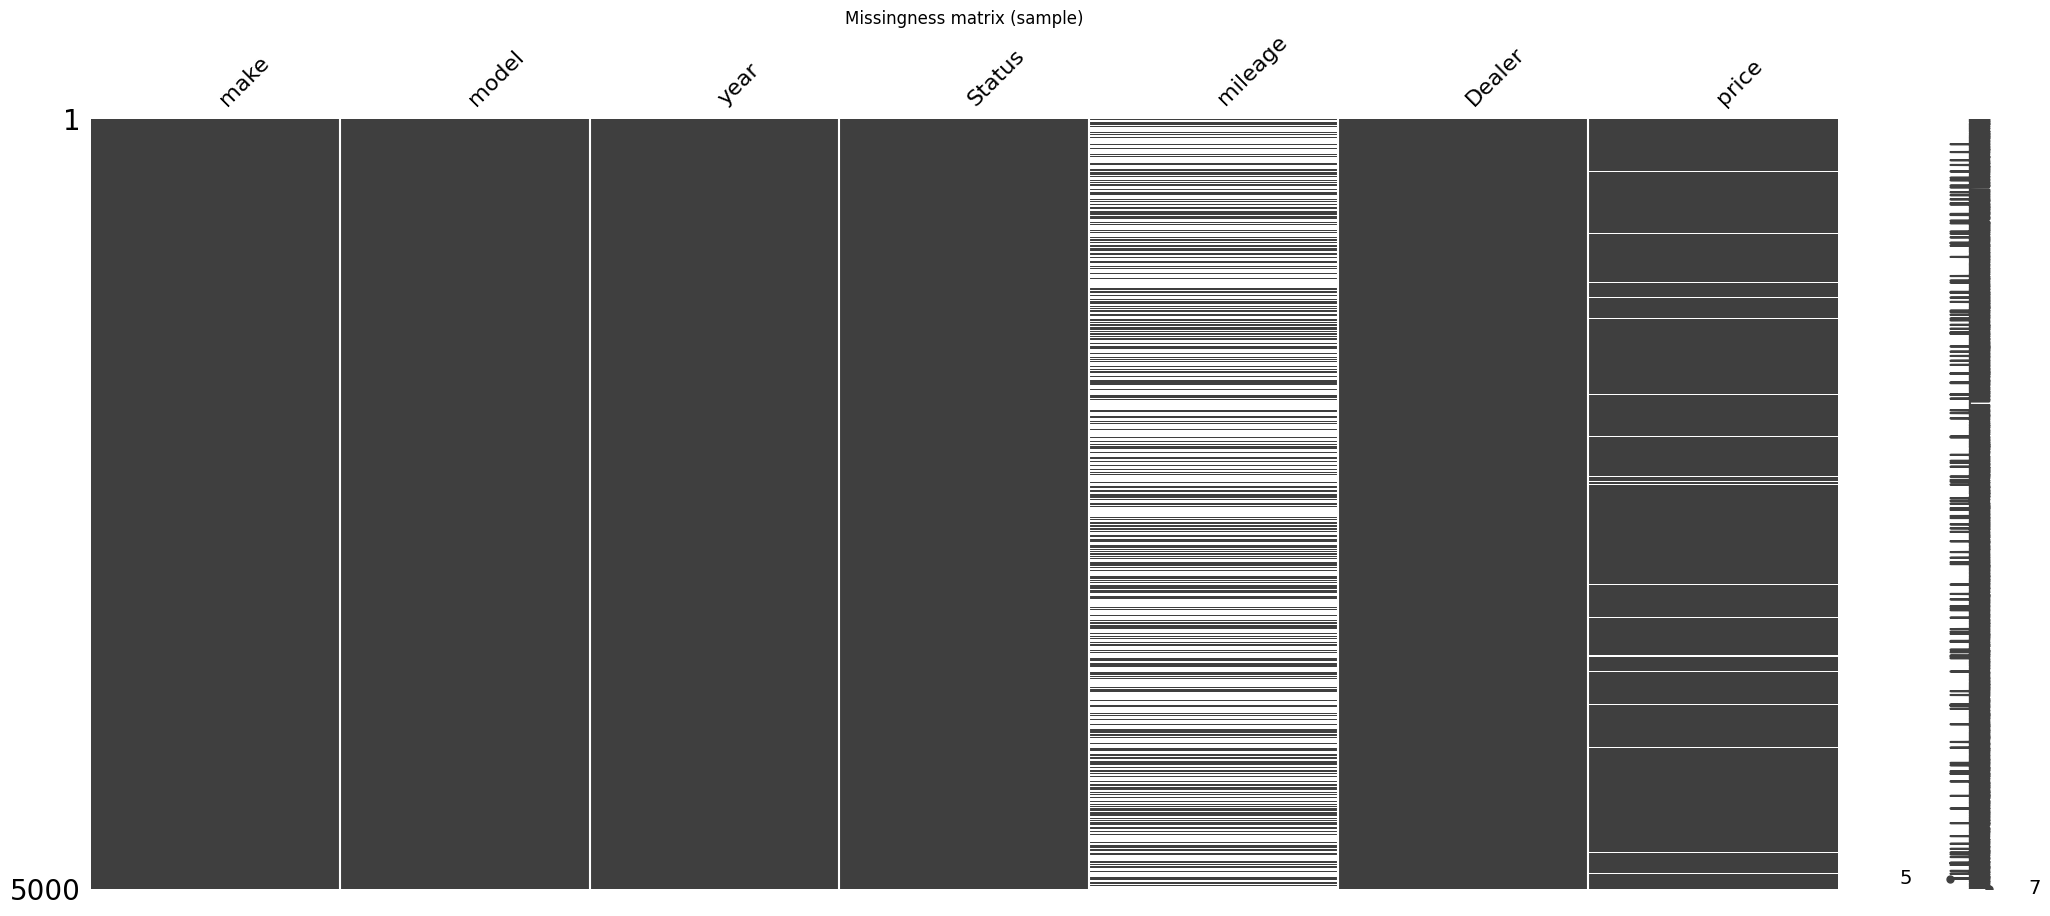

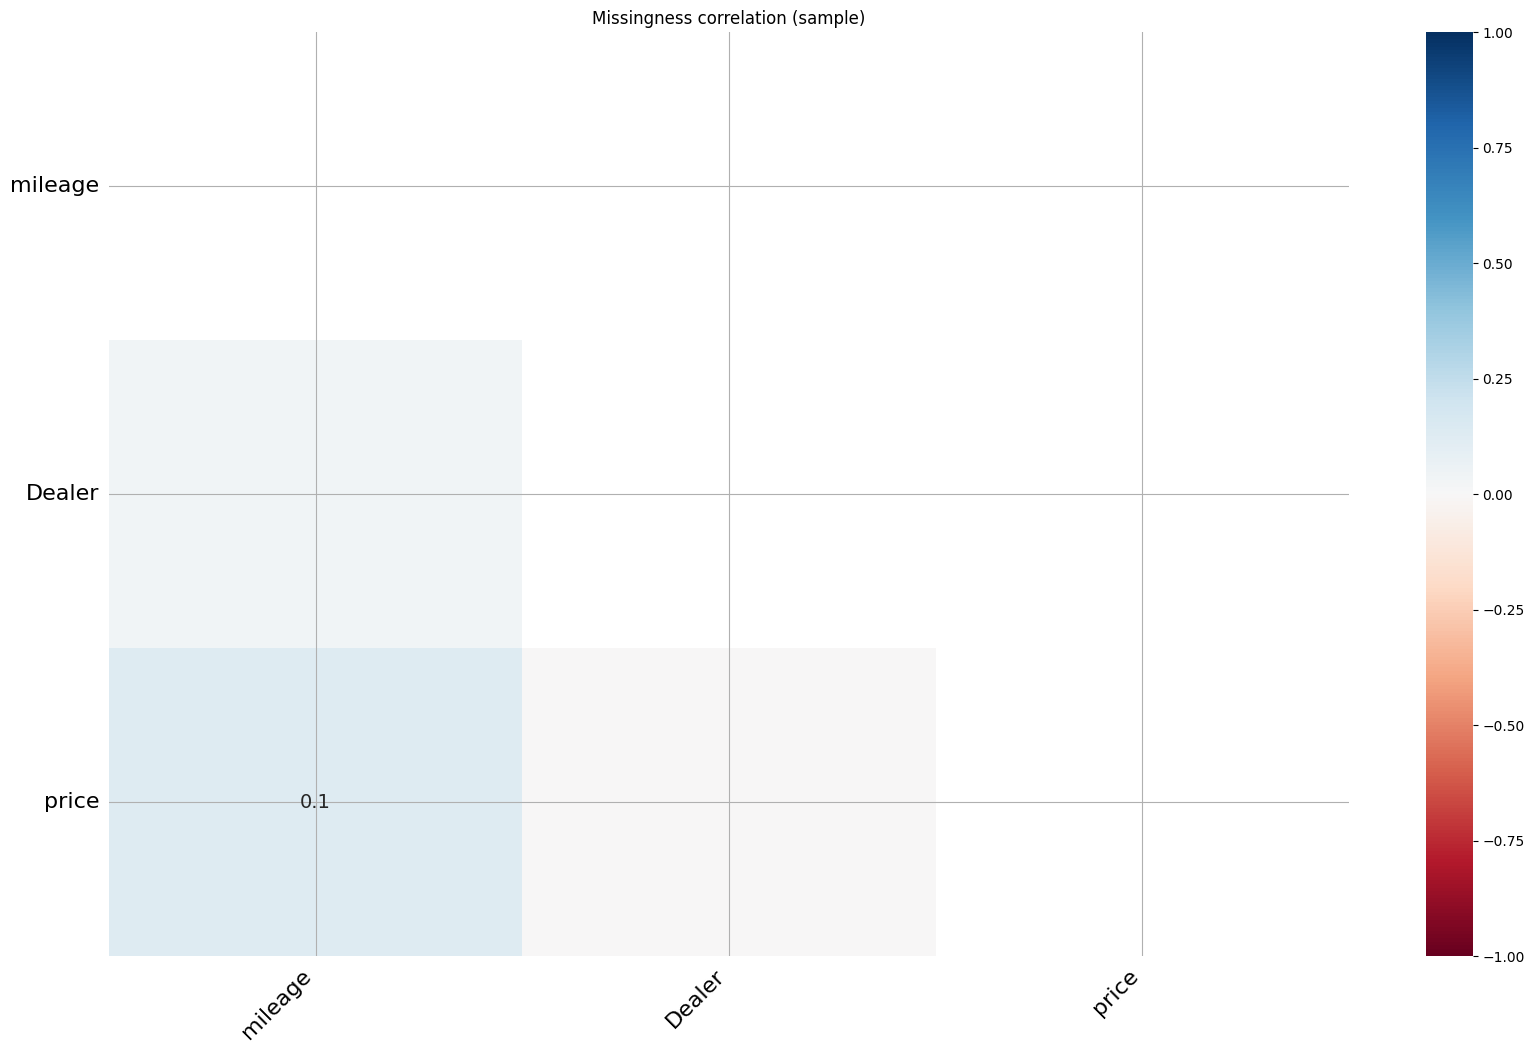

In [17]:
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())

null_pct = df.isna().mean().sort_values(ascending=False)
display(null_pct.to_frame("null_fraction").head(25))

# Visual missingness (skip if dataset is huge)
try:
    msno.matrix(df.sample(min(len(df), 5000), random_state=0))
    plt.title("Missingness matrix (sample)"); plt.show()
    msno.heatmap(df.sample(min(len(df), 15000), random_state=0))
    plt.title("Missingness correlation (sample)"); plt.show()
except Exception as e:
    print("missingno plot skipped:", e)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,144867.0,2021.374716,3.995397,1959.0,2006.00,2013.00,2021.0,2023.0,2024.00,2024.0,2024.00,2024.0
mileage,55914.0,52720.606485,44014.784892,0.0,735.26,3763.65,20116.0,41417.5,73590.75,139250.1,198100.22,419096.0
price,140956.0,52678.891995,42215.037393,1.0,7897.55,14988.00,32110.0,47072.0,65311.25,102690.0,166522.25,8078160.0


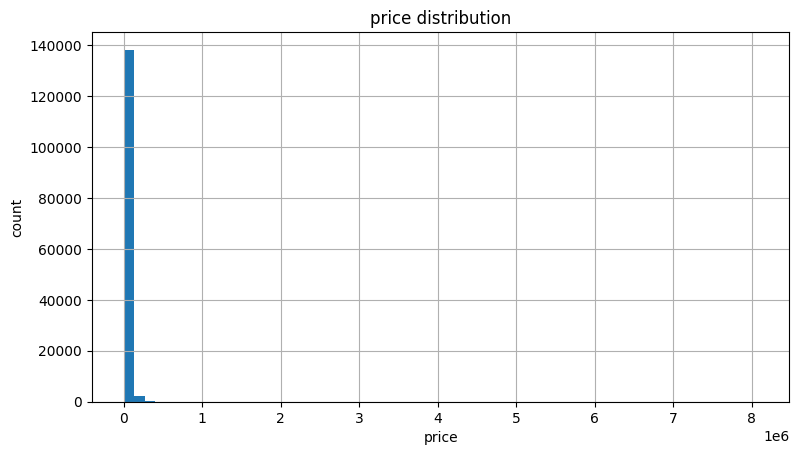

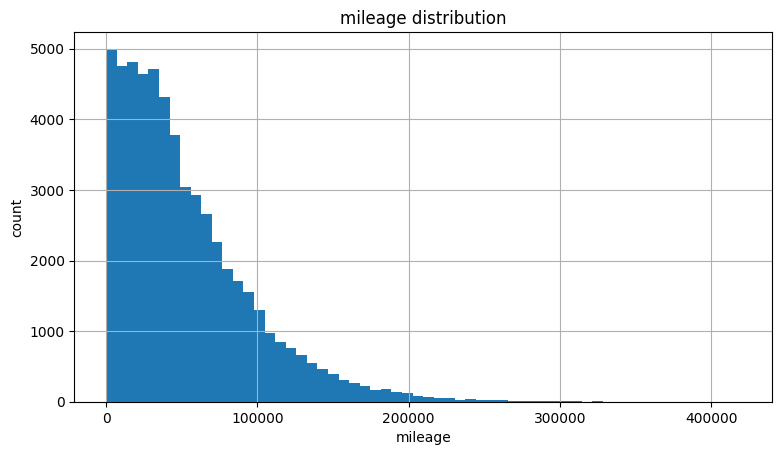

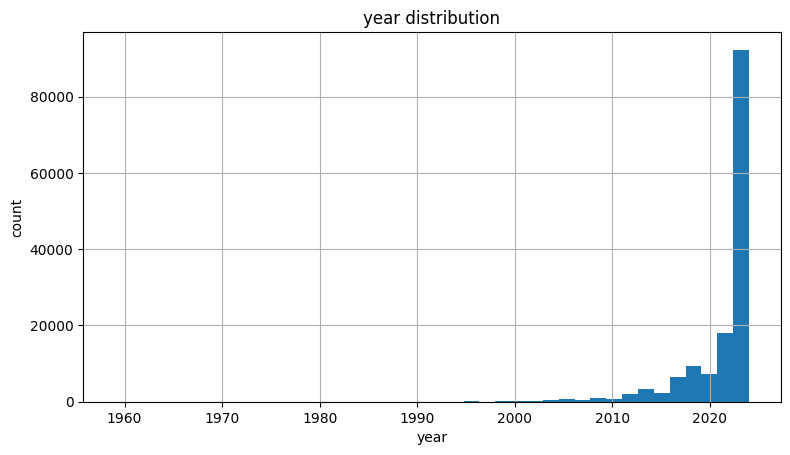

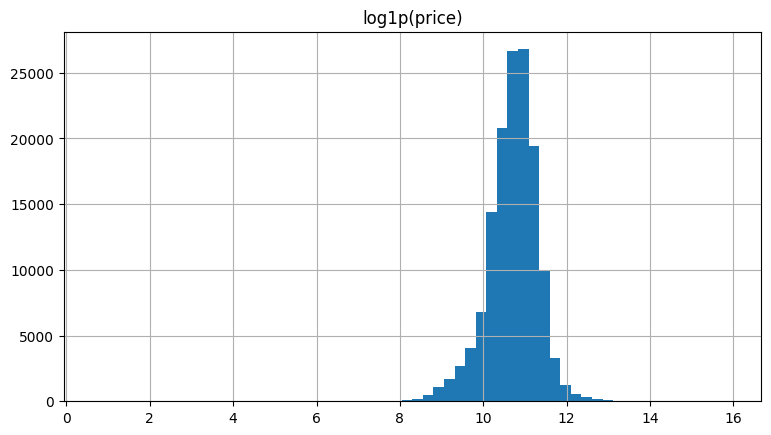

In [18]:
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
display(df[num_cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)

def hist(col, bins=50):
    if col in df:
        vals = df[col].replace([np.inf,-np.inf], np.nan).dropna()
        plt.figure(); plt.hist(vals, bins=bins); plt.title(f"{col} distribution"); plt.xlabel(col); plt.ylabel("count"); plt.show()

hist("price", bins=60)
hist("mileage", bins=60)
hist("year", bins=40)

if "price" in df:
    logp = np.log1p(df["price"].clip(lower=1))
    plt.figure(); plt.hist(logp, bins=60); plt.title("log1p(price)"); plt.show()

In [19]:
cat_cols = [c for c in df.columns if df[c].dtype == "object"]
cat_uniques = pd.Series({c: int(df[c].nunique(dropna=True)) for c in cat_cols}).sort_values(ascending=False)
display(cat_uniques.to_frame("n_unique"))

def top_counts(col, n=20):
    if col in df:
        vc = df[col].astype(str).str.strip().str.lower().value_counts()
        display(vc.head(n).rename_axis(col).to_frame("count"))

top_counts("make", 25)
top_counts("model", 25)

,n_unique
Dealer,11475
model,642
make,62
Status,3


,count
make,
ford,17504
chevrolet,14827
toyota,14573
jeep,8466
gmc,7529
bmw,7233
honda,6168
mercedes,5830
lexus,5385


,count
model,
f-150,4558
silverado,4438
sierra,3705
grand cherokee,3051
1500,2714
mustang,2680
wrangler,2477
yukon,2343
tundra,2312


In [20]:
def simple_canon_make(x):
    s = str(x).lower()
    aliases = {
        "mercedesbenz":"mercedes-benz","mercedes":"mercedes-benz","benz":"mercedes-benz",
        "vw":"volkswagen","volkswagon":"volkswagen","wolkswagen":"volkswagen",
        "chevy":"chevrolet","cheverolet":"chevrolet","cheverlet":"chevrolet",
        "landrover":"land rover","range rover":"land rover","rangerover":"land rover",
        "infinity":"infiniti","porche":"porsche","hyndai":"hyundai","hyundia":"hyundai",
        "lexsus":"lexus","mitsubushi":"mitsubishi","cadilac":"cadillac","bwm":"bmw","b m w":"bmw",
        "ram":"ram"
    }
    for k,v in aliases.items():
        if k in s: return v.title() if v not in {"ram"} else "RAM"
    if "bmw" in s: return "BMW"
    return str(x).strip().title() if pd.notna(x) else np.nan

if "make" in df:
    canon = df["make"].apply(simple_canon_make)
    print("Unique makes BEFORE:", df["make"].nunique())
    print("Unique makes AFTER :", canon.nunique())
    changes = pd.DataFrame({"raw_make": df["make"], "canon_make": canon})
    changes = changes[changes["raw_make"].str.lower() != changes["canon_make"].str.lower()]
    display(changes.head(15))

Unique makes BEFORE: 62
Unique makes AFTER : 62


,raw_make,canon_make
115,Mercedes,Mercedes-Benz
117,Mercedes,Mercedes-Benz
120,Mercedes,Mercedes-Benz
122,Mercedes,Mercedes-Benz
142,Mercedes,Mercedes-Benz
190,Mercedes,Mercedes-Benz
191,Mercedes,Mercedes-Benz
201,Mercedes,Mercedes-Benz
202,Mercedes,Mercedes-Benz
204,Mercedes,Mercedes-Benz


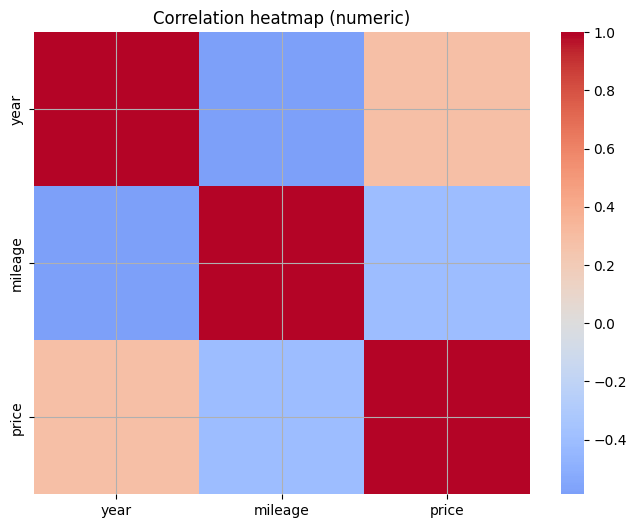

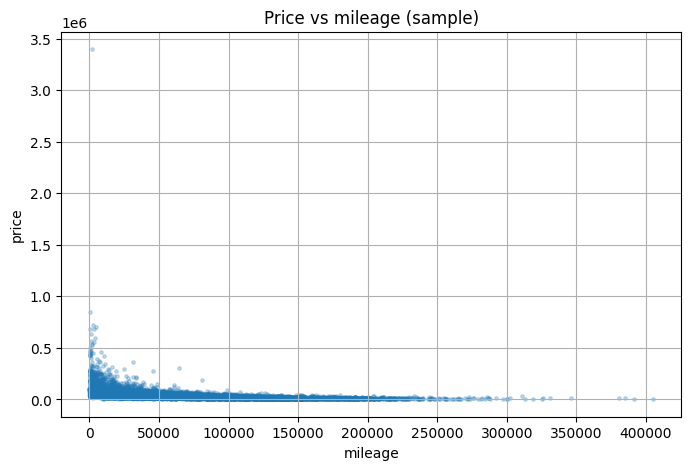

In [21]:
# numeric correlations
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation heatmap (numeric)"); plt.show()

# price vs mileage scatter (downsample)
if {"price","mileage"}.issubset(df.columns):
    sample = df[["price","mileage"]].dropna().sample(min(20000, len(df)), random_state=0)
    plt.figure(figsize=(8,5))
    plt.scatter(sample["mileage"], sample["price"], s=6, alpha=.25)
    plt.xlabel("mileage"); plt.ylabel("price"); plt.title("Price vs mileage (sample)")
    plt.show()

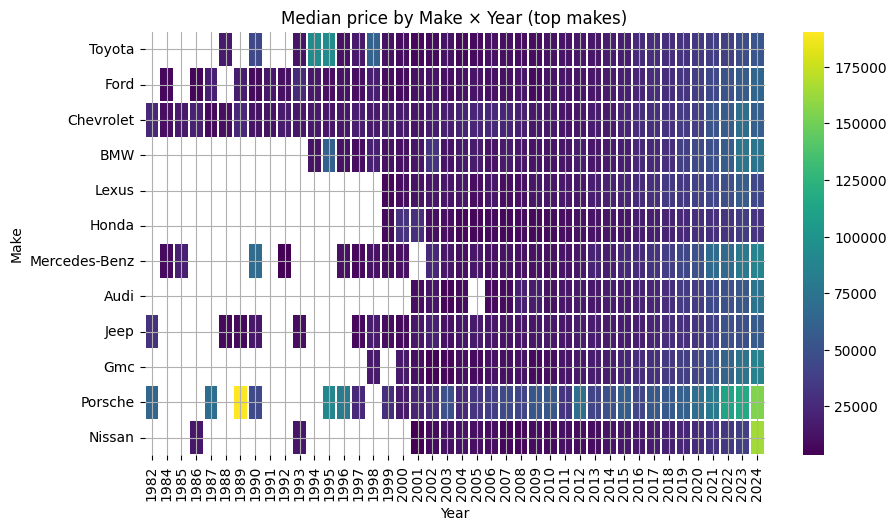

In [29]:
if {"price","year","make"}.issubset(df.columns):
    make_c = df["make"].apply(simple_canon_make)
    topN = 12
    top_makes = make_c.value_counts().head(topN).index
    tmp = df.copy(); tmp["make"] = make_c
    z = (tmp[tmp["make"].isin(top_makes)]
            .groupby(["make","year"])["price"]
            .median()
            .unstack("year"))
    z = z.loc[top_makes]

    plt.figure(figsize=(10, 5.5))
    sns.heatmap(z, cmap="viridis", linewidths=.2)
    plt.title("Median price by Make × Year (top makes)"); plt.ylabel("Make"); plt.xlabel("Year")
    plt.show()

In [30]:
if "price" in df:
    print("Top 10 most expensive:")
    display(df.sort_values("price", ascending=False).head(10)[["make","model","year","mileage","price"]])
    print("Bottom 10 cheapest (non-zero price):")
    display(df[df["price"]>0].sort_values("price", ascending=True).head(10)[["make","model","year","mileage","price"]])

Top 10 most expensive:


,make,model,year,mileage,price
20143,Lamborghini,Coupe,2021,9398.0,250000.0
3012,Porsche,911,2021,5412.0,250000.0
102328,Porsche,911,2022,5006.0,249999.0
69151,Porsche,911,2023,607.0,249999.0
114260,Porsche,911,2021,7539.0,249995.0
42428,Chevrolet,Corvette,2023,429.0,249988.0
37768,Porsche,911,2019,8125.0,249942.0
10611,Lamborghini,Urus,2021,14869.0,249900.0
104420,Land Rover,Defender,1986,70236.0,249887.0
126983,Porsche,Cayman,2023,222.0,249585.0


Bottom 10 cheapest (non-zero price):


,make,model,year,mileage,price
27110,Ford,F-150,2000,217000.0,1699.0
141259,Cadillac,DTS,2006,190113.0,1990.0
141272,Ford,Focus,2004,177084.0,1990.0
8260,Chrysler,LX,2008,287850.0,1995.0
137057,Ford,F-150,1997,180270.0,2000.0
84915,GMC,Yukon,2004,228301.0,2000.0
144776,Ford,Escape,2006,246992.0,2250.0
12495,Chevrolet,Impala,2010,297990.0,2387.0
25941,Saturn,XE,2008,187021.0,2500.0
101406,Mazda,Mazda3,2006,201222.0,2588.0


In [31]:
dup_all = df.duplicated().sum()
print("Exact duplicate rows:", dup_all)

# A looser “key” for near-duplicates (tweak as needed)
key_cols = [c for c in ["make","model","year","mileage","price"] if c in df.columns]
if key_cols:
    dup_key = df.duplicated(subset=key_cols).sum()
    print(f"Duplicates on {key_cols}:", dup_key)

Exact duplicate rows: 0
Duplicates on ['make', 'model', 'year', 'mileage', 'price']: 2


In [32]:
if "price" in df:
    logp = np.log1p(df["price"])
    z = (logp - logp.mean()) / logp.std(ddof=0)
    keep = z.abs() <= 3.5   # keep within ~3.5σ on log scale
    print("Outlier rows (log-price z>|3.5|) dropped:", int((~keep).sum()))
    df = df[keep]

Outlier rows (log-price z>|3.5|) dropped: 49


Shape after cleaning: (54346, 10)


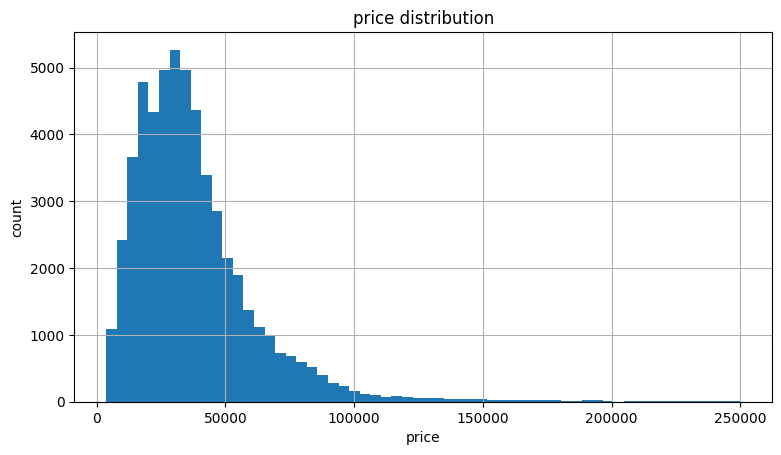

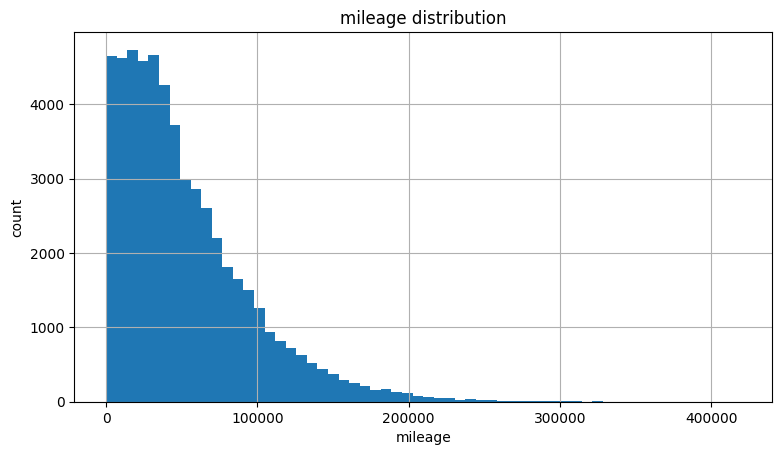

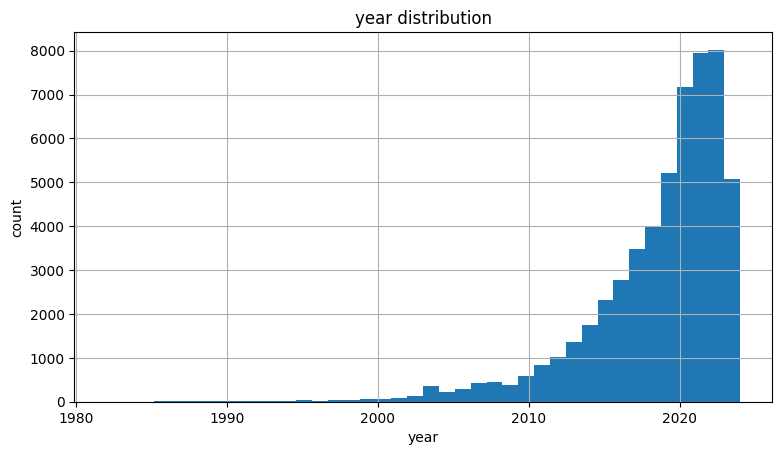

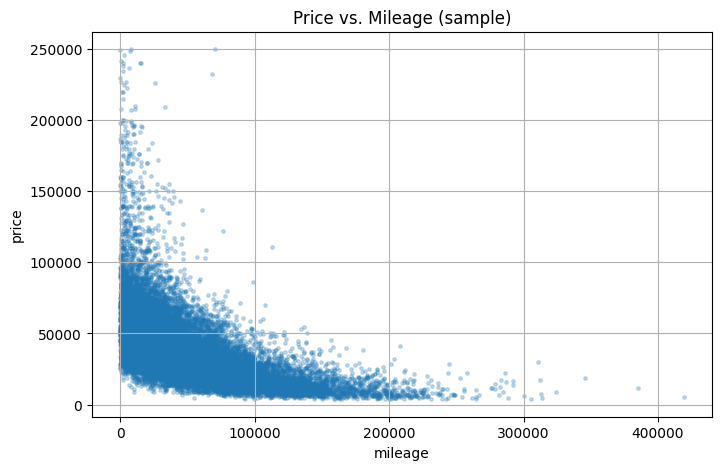

In [33]:
def hist(col, bins=50):
    if col in df:
        vals = df[col].replace([np.inf,-np.inf], np.nan).dropna()
        plt.figure(); plt.hist(vals, bins=bins); plt.title(f"{col} distribution"); plt.xlabel(col); plt.ylabel("count"); plt.show()

print("Shape after cleaning:", df.shape)
hist("price", 60)
hist("mileage", 60)
hist("year", 40)

if {"price","mileage"}.issubset(df.columns):
    samp = df[["price","mileage"]].dropna().sample(min(20000, len(df)), random_state=0)
    plt.figure(figsize=(8,5))
    plt.scatter(samp["mileage"], samp["price"], s=6, alpha=.25)
    plt.title("Price vs. Mileage (sample)"); plt.xlabel("mileage"); plt.ylabel("price"); plt.show()

In [35]:
from pathlib import Path
import os, json

# --- recover the source path robustly ---
if 'SRC' in locals() and isinstance(SRC, (str, Path)):
    src_path = Path(SRC)
else:
    env_p = os.getenv("DATA_CSV")
    if env_p and Path(env_p).exists():
        src_path = Path(env_p)
    else:
        # search common locations
        search = [
            Path("cars.csv"),
            Path("data/cars.csv"),
            Path("data/new/cars.csv"),
            *Path("data").glob("**/cars.csv"),
        ]
        src_path = next((p for p in search if p.exists()), Path("cars.csv"))  # fallback

# --- guard ref_year too (in case that cell wasn't run) ---
ref_year_val = int(ref_year) if 'ref_year' in locals() else int(pd.Timestamp.now().year)

report = {
    "source_file": str(src_path),
    "rows_final": int(len(df)),
    "cols": df.columns.tolist(),
    "ref_year": ref_year_val,
    "filters": {
        "price_range": [500, 250000] if "price" in df else None,
        "mileage_range": [0, 500000] if "mileage" in df else None,
        "year_range": [1980, ref_year_val+1] if "year" in df else None,
        "rare_model_min_support": 15
    },
    "units": {"mileage": "miles"},
    "feature_engineering": [
        c for c in ["age","mileage_per_year","high_mileage"] if c in df.columns
    ],
    "unique_makes": int(df["make"].nunique()) if "make" in df else None,
    "unique_models": int(df["model"].nunique()) if "model" in df else None,
}

# show + save
report
Path("model").mkdir(parents=True, exist_ok=True)
with open("model/cleaning_report_notebook.json", "w") as f:
    json.dump(report, f, indent=2)
print("✅ Saved model/cleaning_report_notebook.json")

✅ Saved model/cleaning_report_notebook.json


In [36]:
Path("data").mkdir(parents=True, exist_ok=True)
out_path = Path("data/clean_used_cars.csv")
df.to_csv(out_path, index=False)
print("✅ Saved:", out_path.resolve())
display(df.head(5))

✅ Saved: /workspaces/used-car-price-app/notebooks/data/clean_used_cars.csv


,make,model,year,Status,mileage,Dealer,price,age,mileage_per_year,high_mileage
3,Ford,Bronco,2023,Used,1551.0,Mike Smith Chrysler Dodge Jeep RAM,58900.0,2,775.500000,0
4,Acura,TLX,2021,Used,30384.0,Mike Smith Nissan,34499.0,4,7596.000000,0
5,Volkswagen,Golf,2022,Certified,13895.0,Volkswagen of Beaumont,34000.0,3,4631.666667,0
6,GMC,Yukon,2021,Used,68506.0,BMW of Beaumont,56954.0,4,17126.500000,0
16,Infiniti,QX30,2019,Used,29009.0,Volkswagen of Lake Charles,23589.0,6,4834.833333,0
